# Notebook 11d — Momentum/Breakout Transfer: Results Summary


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import matplotlib.pyplot as plt

TMP = "tmp"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


fig_n = [0]


def show(fig, caption):
    fig_n[0] += 1
    print(f"Figure {fig_n[0]}: {caption}")
    plt.tight_layout()
    plt.show()

## Phase 0 — Universe and raw-signal diagnostics

Two pre-registered gates: **Gate MB** (30 crypto perpetuals, including
`LUNAUSDT` and `FTTUSDT`, delisted in effect) and **Gate MB-E** (69-ticker
commodity-equity universe). Phase 0 confirms the breakout rule is neither
degenerate nor vacuous: 71 raw signals across the 30 crypto symbols, 1,193
across the 69 equity symbols, with the regime gate open 54.1% / 58.8% of the
time respectively — plausible base rates for a trend-following filter, not a
coin flip or never-opening gate.


In [2]:
phase0 = load("phase_0_11d_results.json")
print("Phase 0 universe and raw-signal diagnostics:")
print(
    f"  Crypto: {phase0['n_crypto_symbols']} symbols, "
    f"{phase0['total_crypto_raw_signals']} raw signals, "
    f"regime gate open {100 * phase0['crypto_regime_ok_frac']:.1f}% of time"
)
print(
    f"  Equity: {phase0['n_equity_symbols']} symbols, "
    f"{phase0['total_equity_raw_signals']} raw signals, "
    f"regime gate open {100 * phase0['equity_regime_ok_frac']:.1f}% of time"
)
print(f"  Dev window end: {phase0['dev_end']}")
print(f"  Delisted crypto present: {phase0['delisted_crypto_present']}")

Phase 0 universe and raw-signal diagnostics:
  Crypto: 30 symbols, 71 raw signals, regime gate open 54.1% of time
  Equity: 69 symbols, 1193 raw signals, regime gate open 58.9% of time
  Dev window end: 2024-12-31
  Delisted crypto present: ['FTTUSDT', 'LUNAUSDT']


## Phase 1 — Gate MB (crypto): positive Sharpe everywhere, noise floor binds

| offset | Sharpe (1×) | Sharpe (2×) | Sharpe (3×) |
|---|---:|---:|---:|
| 0 | +0.173 | +0.166 | +0.159 |
| 7 | +0.174 | — | — |
| 14 | +0.241 | — | — |
| 21 | +0.311 | — | — |

Offset-0, 1× book: 42 trades over 3.5 years, max drawdown −35.5%, fixed-notional
return +9.30%. The noise floor is the binding constraint: 95% CI [−52.7%,
+100.1%] (±76.4pp half-width on 42 trades) contains zero by a wide margin. The
deflated Sharpe probability for `n_trials=12` is 0.055, well below the 0.95
bar. Cost stress (1× vs 3×) is real and statistically distinguishable from
zero (delta −1.48pp, CI [−2.37pp, −0.70pp]) but economically small relative to
the noise floor. **Gate MB does not fire.**


In [3]:
phase1 = load("phase_1_11d_results.json")
print("Gate MB (Crypto) — Phase 1 results:")
print(f"  n_trials: {phase1['n_trials']}")
print("  Sharpe by offset (1× cost):")
for offset_key in ["offset_0", "offset_7", "offset_14", "offset_21"]:
    sharpe = phase1["sharpes_1x_by_offset"].get(offset_key)
    print(f"    {offset_key}: {sharpe:.3f}")
print(f"  Positive every offset: {phase1['positive_every_offset']}")
print("  Noise floor (offset 0, 1×):")
nf = phase1["noise_floor_offset0_1x"]
print(f"    point return: {nf['point_return']:.4f}")
print(f"    95% CI: [{nf['ci_return'][0]:.4f}, {nf['ci_return'][1]:.4f}]")
print(f"    half-width: {nf['half_width_pp']:.1f}pp")
print(f"    CI excludes zero: {phase1['ci_excludes_zero']}")
print("  Cost stress (1× vs 3×, offset 0):")
cs = phase1["cost_stress_1x_vs_3x_offset0"]
print(f"    delta point: {cs['delta_point']:.4f}")
print(f"    delta 95% CI: [{cs['delta_ci'][0]:.4f}, {cs['delta_ci'][1]:.4f}]")
print(f"    delta excludes zero: {cs['delta_excludes_zero']}")
print(f"  Deflated Sharpe prob (n_trials=12): {phase1['deflated_sharpe_prob']:.3f}")
print(f"  DSR fires: {phase1['dsr_fires']}")
print(f"  Gate MB fires: {phase1['gate_fires']}")
print(f"  n_trades (offset 0, 1×): {phase1['n_trades_offset0_1x']}")
print(f"  n_delisted trades: {phase1['n_delisted_trades_offset0_1x']}")
print(f"  delisted_pnl_sum: ${phase1['delisted_pnl_sum']:,.2f}")

Gate MB (Crypto) — Phase 1 results:
  n_trials: 12
  Sharpe by offset (1× cost):
    offset_0: 0.173
    offset_7: 0.174
    offset_14: 0.241
    offset_21: 0.311
  Positive every offset: True
  Noise floor (offset 0, 1×):
    point return: 0.0930
    95% CI: [-0.5266, 1.0007]
    half-width: 76.4pp
    CI excludes zero: False
  Cost stress (1× vs 3×, offset 0):
    delta point: -0.0148
    delta 95% CI: [-0.0237, -0.0070]
    delta excludes zero: True
  Deflated Sharpe prob (n_trials=12): 0.055
  DSR fires: False
  Gate MB fires: False
  n_trades (offset 0, 1×): 42
  n_delisted trades: 1
  delisted_pnl_sum: $-20,181.81


Figure 1: Gate MB Sharpe ranges from 0.173 to 0.311 across four offsets, all positive.


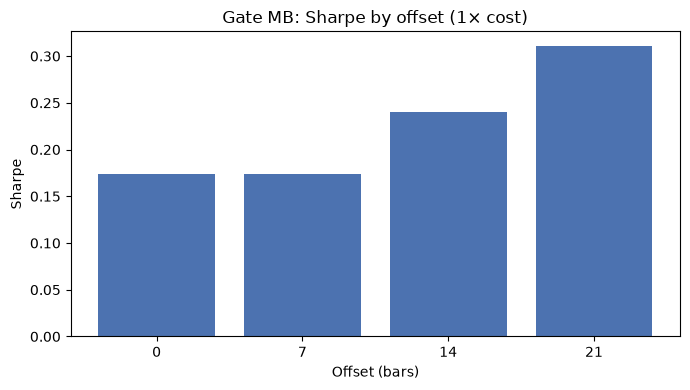

In [4]:
# Chart 1: Gate MB Sharpe by offset (1× cost)
fig, ax = plt.subplots(figsize=(7, 4))
offset_keys = ["offset_0", "offset_7", "offset_14", "offset_21"]
sharpes = [phase1["sharpes_1x_by_offset"][k] for k in offset_keys]
colors = ["#4C72B0"] * len(offset_keys)
ax.bar(["0", "7", "14", "21"], sharpes, color=colors)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.set_xlabel("Offset (bars)")
ax.set_ylabel("Sharpe")
ax.set_title("Gate MB: Sharpe by offset (1× cost)")
ax.set_ylim(bottom=0)
show(
    fig, "Gate MB Sharpe ranges from 0.173 to 0.311 across four offsets, all positive."
)

Figure 2: Point return +9.30%, 95% CI [-52.7%, 100.1%] — contains zero.


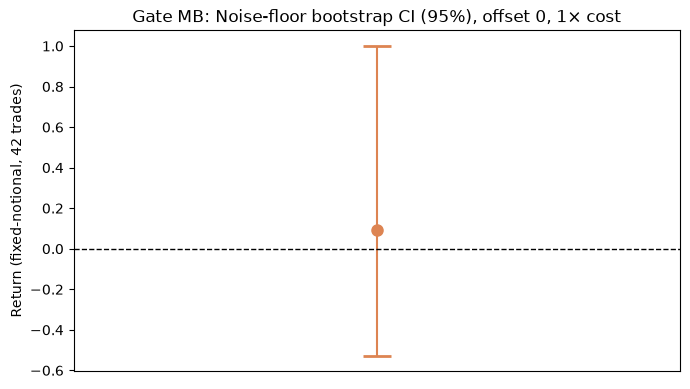

In [5]:
# Chart 2: Gate MB noise-floor bootstrap CI (offset 0, 1×)
fig, ax = plt.subplots(figsize=(7, 4))
nf = phase1["noise_floor_offset0_1x"]
point = nf["point_return"]
ci_low, ci_high = nf["ci_return"]
ax.errorbar(
    [0],
    [point],
    yerr=[[point - ci_low], [ci_high - point]],
    fmt="o",
    markersize=8,
    capsize=10,
    capthick=2,
    color="#DD8452",
)
ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel("Return (fixed-notional, 42 trades)")
ax.set_title("Gate MB: Noise-floor bootstrap CI (95%), offset 0, 1× cost")
show(
    fig,
    f"Point return +9.30%, 95% CI [{ci_low * 100:.1f}%, {ci_high * 100:.1f}%] — contains zero.",
)

## Phase 2 — Gate MB-E (equity): net negative at every offset, fails outright

| offset | Sharpe (1×) |
|---|---:|
| 0 | −0.022 |
| 7 | −0.022 |
| 14 | −0.022 |
| 21 | −0.027 |

401 trades, max drawdown −32.0%, fixed-notional return −19.6%, return/drawdown
−0.61. Net Sharpe is negative at every offset — Gate MB-E's first leg fails
outright. The noise-floor CI ([−111.1%, +81.1%], point −19.6%) and DSR
(0.140 at `n_trials=4`) are reported for completeness but are moot. The breakout
rule reverses sign on the equity side while holding on the crypto side — the
same rule applied to a slower-moving, lower-beta commodity-equity/ETF universe.
**Gate MB-E does not fire**, and was never eligible for a fundable verdict given
the survivorship-unknown universe.


In [6]:
phase2 = load("phase_2_11d_results.json")
print("Gate MB-E (Equity) — Phase 2 results:")
print(f"  n_trials: {phase2['n_trials']}")
print("  Sharpe by offset (1× cost):")
for offset_key in ["offset_0", "offset_7", "offset_14", "offset_21"]:
    sharpe = phase2["sharpes_1x_by_offset"].get(offset_key)
    print(f"    {offset_key}: {sharpe:.4f}")
print(f"  Positive every offset: {phase2['positive_every_offset']}")
print("  Noise floor (offset 0, 1×):")
nf = phase2["noise_floor_offset0_1x"]
print(f"    point return: {nf['point_return']:.4f}")
print(f"    95% CI: [{nf['ci_return'][0]:.4f}, {nf['ci_return'][1]:.4f}]")
print(f"    half-width: {nf['half_width_pp']:.1f}pp")
print(f"  Deflated Sharpe prob (n_trials=4): {phase2['deflated_sharpe_prob']:.3f}")
print(f"  DSR fires: {phase2['dsr_fires']}")
print(f"  Gate MB-E fires: {phase2['gate_fires']}")
print(f"  n_trades (offset 0, 1×): {phase2['n_trades_offset0_1x']}")
print(f"  Fundable flag eligible: {phase2['fundable_flag_eligible']}")
print(f"  Reason: {phase2['fundable_flag_reason']}")

Gate MB-E (Equity) — Phase 2 results:
  n_trials: 4
  Sharpe by offset (1× cost):
    offset_0: -0.0219
    offset_7: -0.0219
    offset_14: -0.0219
    offset_21: -0.0271
  Positive every offset: False
  Noise floor (offset 0, 1×):
    point return: -0.1962
    95% CI: [-1.1107, 0.8111]
    half-width: 96.1pp
  Deflated Sharpe prob (n_trials=4): 0.140
  DSR fires: False
  Gate MB-E fires: False
  n_trades (offset 0, 1×): 401
  Fundable flag eligible: False
  Reason: survivorship-unknown universe cannot support an absolute-performance claim


Figure 3: Gate MB: +0.173. Gate MB-E: −0.022. Same rule, different universes, opposite results.


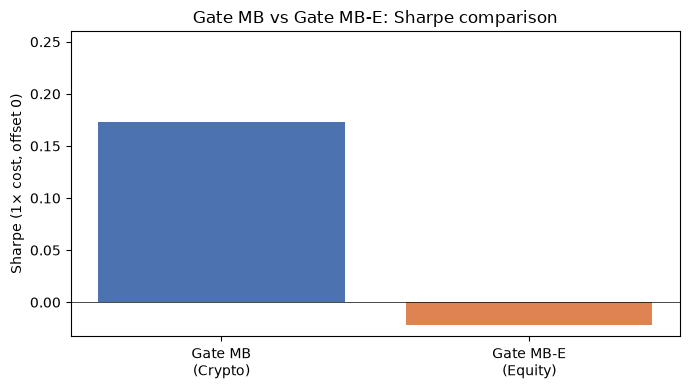

In [7]:
# Chart 3: Gate MB vs Gate MB-E Sharpe comparison (1× cost, offset 0)
fig, ax = plt.subplots(figsize=(7, 4))
gates = ["Gate MB\n(Crypto)", "Gate MB-E\n(Equity)"]
sharpes = [
    phase1["sharpes_1x_by_offset"]["offset_0"],
    phase2["sharpes_1x_by_offset"]["offset_0"],
]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(gates, sharpes, color=colors)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.set_ylabel("Sharpe (1× cost, offset 0)")
ax.set_title("Gate MB vs Gate MB-E: Sharpe comparison")
ax.set_ylim(min(sharpes) * 1.5, max(sharpes) * 1.5)
show(
    fig,
    "Gate MB: +0.173. Gate MB-E: −0.022. Same rule, different universes, opposite results.",
)

## What this notebook establishes, plainly

Both gates are honest nulls, failing for different, informative reasons. Gate
MB's Sharpe is positive everywhere and its cost-stress delta is real and small
— the mechanism is not obviously broken, but 3.5 years of crypto history and 42
trades cannot clear a 12-trial DSR bar, and the noise floor (±76.4pp) governs
the verdict: "cannot be distinguished from noise on this sample." Gate MB-E
fails on its own terms before the statistics matter — net Sharpe is negative at
every offset on a survivorship-unknown universe that the programme's own
governing document says was never eligible for a fundable verdict in the first
place. Consistent with the programme-wide pattern and honest-null discipline:
every-offset check, paired block bootstrap, noise floor, DSR against
pre-registered trial count — remains a success even when point estimates look
promising (Gate MB) or plainly do not (Gate MB-E).
